Training RNN...
Training LSTM...
Training GRU...
Training ViT...


/tmp/ipykernel_7767/1939013597.py:132: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(start=df.index[-1], periods=121, freq='M')[1:]


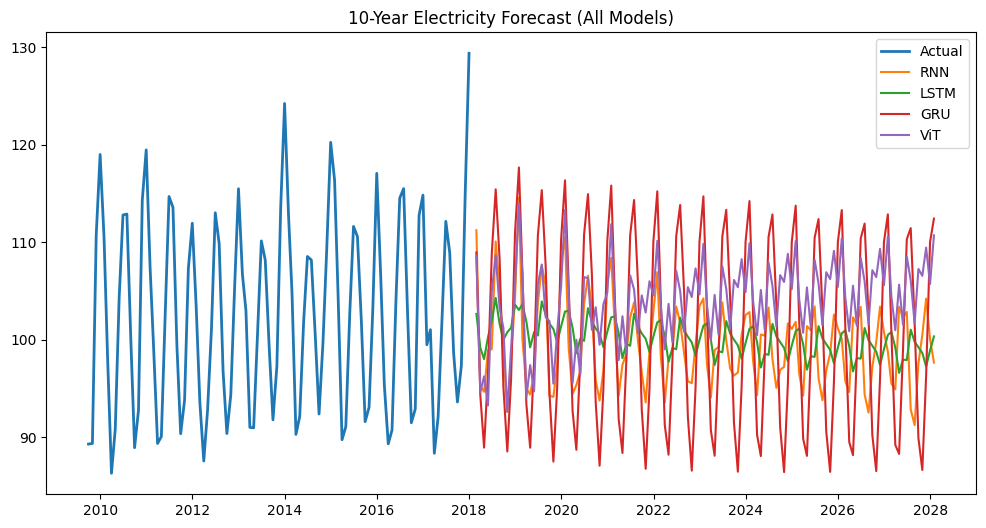

In [12]:
# ================== INSTALL ==================
!pip install tensorflow scikit-learn pandas numpy matplotlib

# ================== IMPORTS ==================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Dropout, Input # Import Input layer
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention, Flatten

# ================== LOAD DATA ==================
df = pd.read_csv('/content/Electric_Production.csv')
df.columns = ['Date', 'Consumption']
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

data = df[['Consumption']].values

# ================== SCALE ==================
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# ================== DATASET ==================
def create_dataset(data, input_steps=36, output_steps=12):
    X, y = [], []
    for i in range(len(data) - input_steps - output_steps):
        X.append(data[i:i+input_steps])
        y.append(data[i+input_steps:i+input_steps+output_steps])
    return np.array(X), np.array(y)

input_steps = 36
output_steps = 12

X, y = create_dataset(data_scaled, input_steps, output_steps)
y = y.reshape(y.shape[0], y.shape[1])

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ================== MODELS ==================
def build_rnn():
    model = Sequential([
        Input(shape=(input_steps,1)), # Use Input layer explicitly
        SimpleRNN(64, return_sequences=True),
        Dropout(0.2),
        SimpleRNN(64),
        Dense(output_steps)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm():
    model = Sequential([
        Input(shape=(input_steps,1)), # Use Input layer explicitly
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dense(output_steps)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru():
    model = Sequential([
        Input(shape=(input_steps,1)), # Use Input layer explicitly
        GRU(128, return_sequences=True),
        Dropout(0.2),
        GRU(64),
        Dense(output_steps)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_vit():
    inputs = Input(shape=(input_steps, 1)) # Define input layer
    x = Dense(64)(inputs)
    x = LayerNormalization()(x)
    # Explicitly pass query, key, and value for MultiHeadAttention
    attention_output = MultiHeadAttention(num_heads=2, key_dim=32)(query=x, value=x, key=x)
    x = Flatten()(attention_output)
    x = Dense(50, activation='relu')(x)
    outputs = Dense(output_steps)(x)
    model = Model(inputs=inputs, outputs=outputs) # Use Functional API to define the model
    model.compile(optimizer='adam', loss='mse')
    return model

models = {
    "RNN": build_rnn(),
    "LSTM": build_lstm(),
    "GRU": build_gru(),
    "ViT": build_vit()
}

trained_models = {}

# ================== TRAIN ==================
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=0)
    trained_models[name] = model

# ================== FORECAST ==================
def forecast(model, data, steps=120):
    current_input = data[-input_steps:]
    preds = []

    while len(preds) < steps:
        pred = model.predict(current_input.reshape(1, input_steps, 1), verbose=0)[0]
        preds.extend(pred)
        current_input = np.append(current_input[len(pred):], pred)

    preds = np.array(preds[:steps]).reshape(-1,1)
    return scaler.inverse_transform(preds)

future_preds = {}

for name, model in trained_models.items():
    future_preds[name] = forecast(model, data_scaled)

# ================== PLOT ==================
plt.figure(figsize=(12,6))

# actual
plt.plot(df.index[-100:], data[-100:], label='Actual', linewidth=2)

# predictions
future_index = pd.date_range(start=df.index[-1], periods=121, freq='ME')[1:] # Changed 'M' to 'ME'

for name, pred in future_preds.items():
    plt.plot(future_index, pred, label=name)

plt.legend()
plt.title("10-Year Electricity Forecast (All Models)")
plt.show()